In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
orders = pd.read_csv("Mock_orders_data.csv")
orders.head()

,User ID,Order ID,Order Status,Merchant,subtotal,tax,fees,promotion,order datetime,delivery datetime,Cancellation reason,NPS,Commission Rate,Is Split Order,Is Manual Reload,Delivery Attempts,Num Items
0,V5SN9,E7T0TSZD,Successful,Zest,8.72,0.50,6.30,5.0,2023-01-01 08:00:00,2023-01-01 08:07:22.474700820,NaN,7,0.12,False,False,1,1
1,3N3BZ,TVIQ16SD,Successful,Zest,14.71,0.85,7.20,5.0,2023-01-01 08:03:00,2023-01-01 08:11:16.113685860,NaN,6,0.12,False,False,1,2
2,U9Q44,HLXJNTRS,Cancelled by Merchant,Zest,9.24,0.53,6.38,5.0,2023-01-01 08:04:00,2023-01-01 08:46:25.435335996,Fulfillment Failure,5,0.12,False,False,1,1
3,MDKRL,3JZPAIJM,Successful,Crust,12.00,0.69,6.79,5.0,2023-01-01 08:18:00,2023-01-01 08:27:13.098435012,NaN,8,0.20,False,False,1,1
4,0V5DT,73NEJV4D,Successful,Zest,14.15,0.81,7.11,5.0,2023-01-01 08:34:00,2023-01-01 08:55:07.008829410,NaN,8,0.12,False,False,1,2


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User ID              15000 non-null  object 
 1   Order ID             15000 non-null  object 
 2   Order Status         15000 non-null  object 
 3   Merchant             15000 non-null  object 
 4   subtotal             15000 non-null  float64
 5   tax                  15000 non-null  float64
 6   fees                 15000 non-null  float64
 7   promotion            15000 non-null  float64
 8   order datetime       15000 non-null  object 
 9   delivery datetime    15000 non-null  object 
 10  Cancellation reason  1464 non-null   object 
 11  NPS                  15000 non-null  int64  
 12  Commission Rate      15000 non-null  float64
 13  Is Split Order       15000 non-null  bool   
 14  Is Manual Reload     15000 non-null  bool   
 15  Delivery Attempts    15000 non-null 

In [4]:
# Changing the datatype of order datetime and delivery datetime columns:

orders['order datetime'] = pd.to_datetime(orders['order datetime'])
orders['delivery datetime'] = pd.to_datetime(orders['delivery datetime'])

# Calculating delivery time in minutes:

orders['delivery_minutes'] = ((orders['delivery datetime'] - orders['order datetime']).dt.total_seconds() / 60).round(2)

# Extracting date from delivery date:

orders['delivery_date'] = orders['delivery datetime'].dt.date
orders['delivery_date'] = pd.to_datetime(orders['delivery_date'])

# Extracting year-month from delivery date:

orders['delivery_year_month'] = orders['delivery datetime'].dt.strftime('%Y-%m')

# Creating a Net Revenue column:

orders['net_revenue'] = round((orders['subtotal']*orders['Commission Rate'])+orders['fees']-orders['promotion'],2)

# Creating a column for order hour:

orders['order_hour'] = orders['order datetime'].dt.hour

In [5]:
orders.head()

,User ID,Order ID,Order Status,Merchant,subtotal,tax,fees,promotion,order datetime,delivery datetime,...,Commission Rate,Is Split Order,Is Manual Reload,Delivery Attempts,Num Items,delivery_minutes,delivery_date,delivery_year_month,net_revenue,order_hour
0,V5SN9,E7T0TSZD,Successful,Zest,8.72,0.50,6.30,5.0,2023-01-01 08:00:00,2023-01-01 08:07:22.474700820,...,0.12,False,False,1,1,7.37,2023-01-01,2023-01,2.35,8
1,3N3BZ,TVIQ16SD,Successful,Zest,14.71,0.85,7.20,5.0,2023-01-01 08:03:00,2023-01-01 08:11:16.113685860,...,0.12,False,False,1,2,8.27,2023-01-01,2023-01,3.97,8
2,U9Q44,HLXJNTRS,Cancelled by Merchant,Zest,9.24,0.53,6.38,5.0,2023-01-01 08:04:00,2023-01-01 08:46:25.435335996,...,0.12,False,False,1,1,42.42,2023-01-01,2023-01,2.49,8
3,MDKRL,3JZPAIJM,Successful,Crust,12.00,0.69,6.79,5.0,2023-01-01 08:18:00,2023-01-01 08:27:13.098435012,...,0.20,False,False,1,1,9.22,2023-01-01,2023-01,4.19,8
4,0V5DT,73NEJV4D,Successful,Zest,14.15,0.81,7.11,5.0,2023-01-01 08:34:00,2023-01-01 08:55:07.008829410,...,0.12,False,False,1,2,21.12,2023-01-01,2023-01,3.81,8


In [6]:
orders.groupby('Is Split Order')['NPS'].mean()

Is Split Order
False    7.746953
True     7.765714
Name: NPS, dtype: float64

## Exploratory Data Analysis:

In [7]:
# Number of Unique Merchants:

orders['Merchant'].nunique()

20

In [8]:
# Distribution of Merchants: (Orders Per Merchant in Merchant Performance Dashboard)

orders['Merchant'].value_counts()

Merchant
Vellum                 1226
Hearthstone House      1046
The Copper Kettle      1015
Zest                    964
Marrow                  948
The Tipsy Artichoke     872
Brine                   852
Obsidian Kitchen        840
Kindle & Cane           756
Aura & Ash              753
Crust                   734
The Willow Snug         727
Noodle Theory           720
Fork in the Road        714
Sage & Stone            678
Thistle & Thread        659
Flux                    493
Salt & Spectacle        475
The Gilded Root         433
The Social Sieve         95
Name: count, dtype: int64

In [9]:
# Distribution of Cancellation Reasons:

orders['Cancellation reason'].value_counts()

Cancellation reason
Service Downtime                 302
Merchant Not Accepting Orders    302
Weather Downtime                 296
Fulfillment Failure              292
Item Out of Stock                272
Name: count, dtype: int64

In [10]:
#(Cancellation Reasons Distribution in Customer Experience Dashboard)

orders['Cancellation reason'].value_counts(normalize=True) * 100

Cancellation reason
Service Downtime                 20.628415
Merchant Not Accepting Orders    20.628415
Weather Downtime                 20.218579
Fulfillment Failure              19.945355
Item Out of Stock                18.579235
Name: proportion, dtype: float64

In [11]:
# Distribution of Order Status: (Total Deliveries and Total Cancellations in Home page)

orders['Order Status'].value_counts()

Order Status
Successful               13536
Cancelled by Merchant      969
Cancelled by Zipline       495
Name: count, dtype: int64

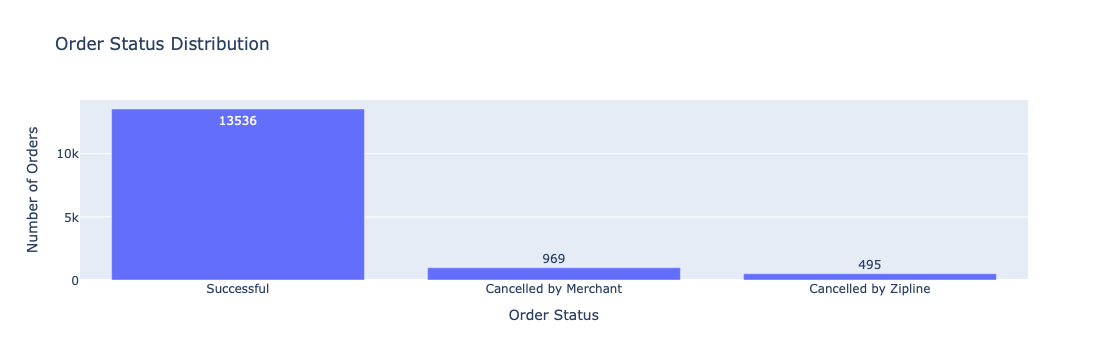

In [12]:
import plotly.express as px

status_counts = orders['Order Status'].value_counts().reset_index()
status_counts.columns = ['Order Status', 'Count']

fig = px.bar(
    status_counts,
    x='Order Status',
    y='Count',
    title='Order Status Distribution',
    text='Count'
)

fig.update_layout(xaxis_title='Order Status', yaxis_title='Number of Orders')

fig.show()

In [13]:
# Distribution of Delivery Attempts:

orders['Delivery Attempts'].value_counts()

Delivery Attempts
1    14565
2      290
3      145
Name: count, dtype: int64

## Home Page KPI Cards:

In [14]:
# Total Net Revenue:

total_net_revenue = orders['net_revenue'].sum().round(2)

# Total Orders:

total_orders = orders['Order ID'].nunique()

# Total Successful Trips:

total_success = len(orders[orders['Order Status'] == 'Successful'])

# Total Cancellations:

total_cancellations = total_orders - total_success

In [15]:
print(f"Total Net Revenue: {total_net_revenue} | Total Orders: {total_orders} | Total Deliveries: {total_success} | Total Cancellations: {total_cancellations}")

Total Net Revenue: 145171.54 | Total Orders: 15000 | Total Deliveries: 13536 | Total Cancellations: 1464


## Customer Experience Dashboard:

In [17]:
# Avg Delivery Time:

avg_delivery_time = orders['delivery_minutes'].mean().round(2)

# Avg NPS:

avg_nps = orders['NPS'].mean().round(2)

# Avg Delivery Attempts: 

avg_delivery_attempts = orders['Delivery Attempts'].median()

# Cancellation Rate:

total_orders = len(orders)
cancelled_orders = len(orders[orders['Order Status'] != 'Successful'])
cancellation_rate = round(cancelled_orders / total_orders,3)

In [18]:
print(
    f"Avg Delivery Time: {avg_delivery_time} mins | "
    f"Avg NPS: {avg_nps} | "
    f"Avg Delivery Attempts: {avg_delivery_attempts} | "
    f"Cancellation Rate: {cancellation_rate:.2%}"
)

Avg Delivery Time: 20.66 mins | Avg NPS: 7.75 | Avg Delivery Attempts: 1.0 | Cancellation Rate: 9.80%


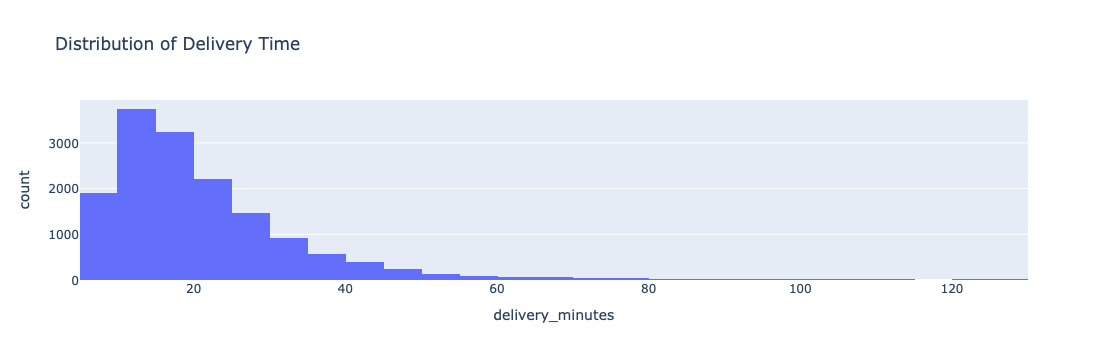

In [19]:
import plotly.express as px

fig = px.histogram(
    orders,
    x='delivery_minutes',   # create this first
    nbins=30,
    title='Distribution of Delivery Time'
)

fig.show()

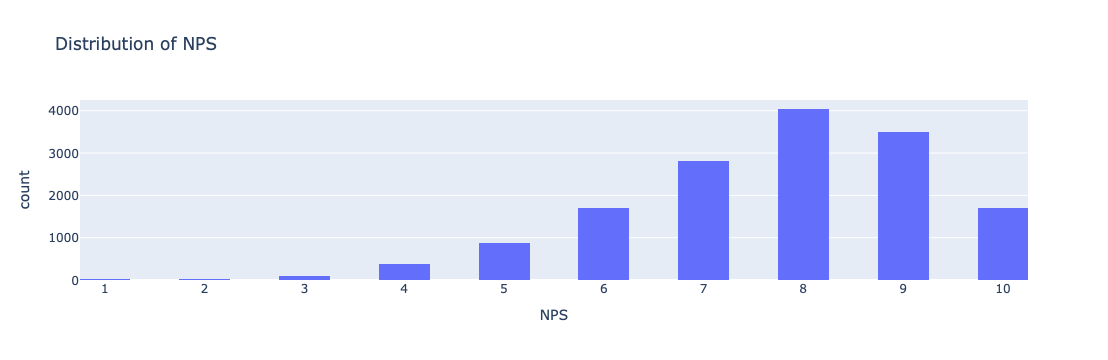

In [20]:
import plotly.express as px

fig = px.histogram(
    orders,
    x='NPS',   # create this first
    nbins=30,
    title='Distribution of NPS'
)

fig.show()

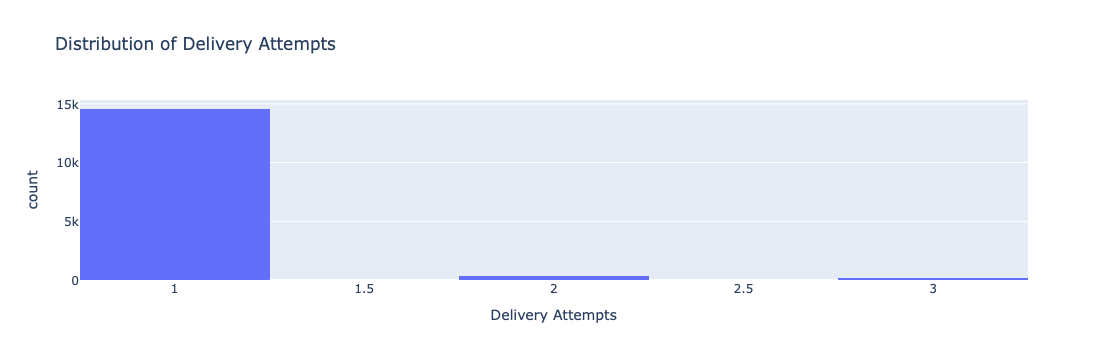

In [21]:
import plotly.express as px

fig = px.histogram(
    orders,
    x='Delivery Attempts',   # create this first
    nbins=10,
    title='Distribution of Delivery Attempts'
)

fig.show()

In [22]:
# Verifying Values in Delivery Time Trend:

avg_delivery_jan18 = orders[
    orders['delivery_date'] == '2023-02-20'
]['delivery_minutes'].mean()

avg_delivery_jan18

np.float64(20.477213114754097)

In [23]:
# Verifying Order Distribution:

orders['order_hour'].value_counts()

order_hour
18    1821
19    1806
17    1315
20    1266
8     1184
12    1172
11    1148
10     998
9      946
21     860
16     788
13     712
15     527
14     457
Name: count, dtype: int64

In [24]:
# Verifying Order Time Distribution:

filtered_orders = orders[
    (orders['order datetime'] >= '2023-01-01') &
    (orders['order datetime'] < '2023-01-19')
]

filtered_orders['order_hour'].value_counts()

order_hour
18    306
19    296
17    218
8     204
12    192
20    187
10    167
11    165
9     146
21    136
16    115
13    111
15     90
14     68
Name: count, dtype: int64

## Customer Growth Dashboard:

In [25]:
# Sort by user and order datetime (chronological first order per user)
orders = orders.sort_values(by=['User ID', 'order datetime'])

# Create customer_type column
orders['customer_type'] = orders.duplicated(subset='User ID', keep='first').map({True: 'Repeat Customer', False: 'New Customer'})

orders.head()

,User ID,Order ID,Order Status,Merchant,subtotal,tax,fees,promotion,order datetime,delivery datetime,...,Is Split Order,Is Manual Reload,Delivery Attempts,Num Items,delivery_minutes,delivery_date,delivery_year_month,net_revenue,order_hour,customer_type
12396,00CRZ,NOMFUG7L,Successful,Aura & Ash,8.97,0.52,3.34,5.0,2023-03-19 13:22:00,2023-03-19 13:33:56.598044988,...,False,False,1,1,11.94,2023-03-19,2023-03,0.13,13,New Customer
2786,00E2Q,4WOBX7HL,Successful,Thistle & Thread,37.07,2.13,7.55,5.0,2023-01-21 18:34:00,2023-01-21 18:41:00.000000000,...,False,True,1,3,7.00,2023-01-21,2023-01,9.96,18,New Customer
12308,00E2Q,3K2LD4P2,Successful,Marrow,14.32,0.82,2.15,0.0,2023-03-18 21:06:00,2023-03-18 21:27:51.054342780,...,False,False,1,1,21.85,2023-03-18,2023-03,5.01,21,Repeat Customer
4633,00N11,50G9W1IR,Successful,Kindle & Cane,19.47,1.12,4.91,5.0,2023-02-02 20:00:00,2023-02-02 20:13:05.645130330,...,False,False,1,2,13.09,2023-02-02,2023-02,3.22,20,New Customer
5595,00N11,BTE6ZRX3,Successful,The Tipsy Artichoke,60.49,3.48,14.06,0.0,2023-02-08 18:31:00,2023-02-08 18:56:13.145186244,...,False,False,1,6,25.22,2023-02-08,2023-02,24.34,18,Repeat Customer


In [26]:
# Verifying the KPI cards in Customer Growth Dashboard:

# Number of Unique Customers:

total_customers = orders['User ID'].nunique()

# Average orders per customer:

avg_orders_per_customer = round(total_orders / total_customers,2)

# Count orders per customer:

orders_per_customer = orders.groupby('User ID').size()

# Number of customers with more than 1 order

repeat_customers = (orders_per_customer > 1).sum()

# Repeat Purchase Rate:

repeat_purchase_rate = round((repeat_customers / total_customers) * 100,2)

In [27]:
print(
    f"Total Customers: {total_customers} | "
    f"Avg Orders/Customer: {avg_orders_per_customer} | "
    f"Repeat Customers: {repeat_customers} | "
    f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%"
)

Total Customers: 4185 | Avg Orders/Customer: 3.58 | Repeat Customers: 3278 | Repeat Purchase Rate: 78.33%


In [28]:
filtered_orders = orders[
    (orders['order datetime'] >= '2023-01-01') &
    (orders['order datetime'] < '2023-01-19')
]

# Number of Unique Customers:

x_total_customers = filtered_orders['User ID'].nunique()

# Average orders per customer:

x_total_orders = len(filtered_orders)

x_avg_orders_per_customer = round(x_total_orders / x_total_customers,2)

# Count orders per customer:

x_orders_per_customer = filtered_orders.groupby('User ID').size()

# Number of customers with more than 1 order

x_repeat_customers = (x_orders_per_customer > 1).sum()

# Repeat Purchase Rate:

x_repeat_purchase_rate = round((x_repeat_customers / x_total_customers) * 100,2)

In [29]:
print(
    f"Total Customers: {x_total_customers} | "
    f"Avg Orders/Customer: {x_avg_orders_per_customer} | "
    f"Repeat Customers: {x_repeat_customers} | "
    f"Repeat Purchase Rate: {x_repeat_purchase_rate:.2f}%"
)

Total Customers: 1752 | Avg Orders/Customer: 1.37 | Repeat Customers: 490 | Repeat Purchase Rate: 27.97%


In [30]:
# Verifying the Weekly Active users Trend Line:

orders['week'] = orders['order datetime'].dt.to_period('W')
wau = orders.groupby('week')['User ID'].nunique().reset_index()
wau.columns = ['week', 'weekly_active_users']
wau

,week,weekly_active_users
0,2022-12-26/2023-01-01,117
1,2023-01-02/2023-01-08,772
2,2023-01-09/2023-01-15,858
3,2023-01-16/2023-01-22,861
4,2023-01-23/2023-01-29,922
5,2023-01-30/2023-02-05,1000
6,2023-02-06/2023-02-12,967
7,2023-02-13/2023-02-19,946
8,2023-02-20/2023-02-26,992
9,2023-02-27/2023-03-05,1100


In [31]:
# Verifying Week over Week Growth Rate:

wau['wow_growth'] = (wau['weekly_active_users'].pct_change() * 100).round(2)

wau['wow_growth']

0        NaN
1     559.83
2      11.14
3       0.35
4       7.08
5       8.46
6      -3.30
7      -2.17
8       4.86
9      10.89
10     -2.18
11      6.88
12      3.83
13    -25.29
Name: wow_growth, dtype: float64

## Financial Results Dashboard:


In [33]:
# Verifying KPI Cards in Financial Results Dashboard:

# Total Net Revenue:

total_net_revenue = orders['net_revenue'].sum().round(2)

# Average Order Value:

aov = round(total_net_revenue / total_orders,2)

# Revenue Per Customer:

revenue_per_customer = round(total_net_revenue/total_customers,2)

# Promotion Rate:

promotion_rate = round(orders['promotion'].sum() / orders['subtotal'].sum(),2)

In [34]:
print(
    f"Total Net Revenue: ${total_net_revenue:,.2f} | "
    f"AOV: ${aov:,.2f} | "
    f"Revenue/Customer: ${revenue_per_customer:,.2f} | "
    f"Promotion Rate: {promotion_rate:.2%}"
)

Total Net Revenue: $145,171.54 | AOV: $9.68 | Revenue/Customer: $34.69 | Promotion Rate: 7.00%


In [35]:
filtered_orders = orders[
    (orders['order datetime'] >= '2023-01-01') &
    (orders['order datetime'] < '2023-01-19')
]

x_total_customers = filtered_orders['User ID'].nunique()
x_total_orders = len(filtered_orders)

# Total Net Revenue:

x_total_net_revenue = filtered_orders['net_revenue'].sum().round(2)

# Average Order Value:

x_aov = round(x_total_net_revenue / x_total_orders,2)

# Revenue Per Customer:

x_revenue_per_customer = round(x_total_net_revenue/x_total_customers,2)

# Promotion Rate:

x_promotion_rate = round(filtered_orders['promotion'].sum() / filtered_orders['subtotal'].sum(),2)

In [36]:
print(
    f"Total Net Revenue: ${x_total_net_revenue:,.2f} | "
    f"AOV: ${x_aov:,.2f} | "
    f"Revenue/Customer: ${x_revenue_per_customer:,.2f} | "
    f"Promotion Rate: {x_promotion_rate:.2%}"
)

Total Net Revenue: $19,938.02 | AOV: $8.30 | Revenue/Customer: $11.38 | Promotion Rate: 13.00%


In [37]:
# Verifying the Daily Revenue Trend Line:

filtered_orders['order_date'] = filtered_orders['order datetime'].dt.date
filtered_orders.groupby('order_date')['net_revenue'].sum()

/var/folders/0c/s6dtq9_n20q5fcdnbr6ml4fc0000gp/T/ipykernel_32125/4097827813.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_orders['order_date'] = filtered_orders['order datetime'].dt.date


order_date
2023-01-01     952.25
2023-01-02     913.42
2023-01-03    1013.97
2023-01-04    1091.39
2023-01-05     855.15
2023-01-06    1176.14
2023-01-07     876.68
2023-01-08    1117.87
2023-01-09    1148.89
2023-01-10    1053.18
2023-01-11    1113.74
2023-01-12    1252.34
2023-01-13    1420.63
2023-01-14    1100.94
2023-01-15    1185.79
2023-01-16    1284.79
2023-01-17    1206.57
2023-01-18    1174.28
Name: net_revenue, dtype: float64

In [38]:
# Orders and Revenue generated by Promotional and Non-Promotional Orders:

filtered_orders['promo_flag'] = filtered_orders['promotion'].apply(lambda x: 'With Promo' if x > 0 else 'No Promo')

promo_summary = (
    filtered_orders
    .groupby('promo_flag')
    .agg(
        total_orders=('Order ID', 'count'),
        net_revenue=('net_revenue', 'sum')
    )
    .reset_index()
)

promo_summary

/var/folders/0c/s6dtq9_n20q5fcdnbr6ml4fc0000gp/T/ipykernel_32125/1531946748.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_orders['promo_flag'] = filtered_orders['promotion'].apply(lambda x: 'With Promo' if x > 0 else 'No Promo')


,promo_flag,total_orders,net_revenue
0,No Promo,560,6494.13
1,With Promo,1841,13443.89


In [39]:
# Orders and Revenue generated by Promotional and Non-Promotional Orders:

orders['promo_flag'] = orders['promotion'].apply(lambda x: 'With Promo' if x > 0 else 'No Promo')

promo_summary = (
    orders
    .groupby('promo_flag')
    .agg(
        total_orders=('Order ID', 'count'),
        net_revenue=('net_revenue', 'sum')
    )
    .reset_index()
)

promo_summary

,promo_flag,total_orders,net_revenue
0,No Promo,9085,104621.15
1,With Promo,5915,40550.39


## Merchant Performance Dashboard:

In [40]:
# Veryfying the merchant performance dashboard:

def cancellation_rate(x):
    return (x != 'Successful').mean()

report_card = filtered_orders.groupby('Merchant').agg(
        orders_per_merchant=('Order ID', 'count'),
        net_revenue_per_merchant=('net_revenue', 'sum'),
        avg_delivery_time_per_merchant=('delivery_minutes', 'mean'),
        cancellation_rate_per_merchant=('Order Status', cancellation_rate),
        avg_NPS_per_merchant=('NPS', 'mean'))

In [41]:
report_card

,orders_per_merchant,net_revenue_per_merchant,avg_delivery_time_per_merchant,cancellation_rate_per_merchant,avg_NPS_per_merchant
Merchant,,,,,
Aura & Ash,113,141.20,17.964071,0.115044,8.256637
Brine,127,709.30,19.383071,0.070866,8.086614
Crust,131,579.18,18.666489,0.053435,8.183206
Flux,78,315.32,18.397051,0.115385,8.282051
Fork in the Road,124,983.38,19.321210,0.137097,7.838710
Hearthstone House,161,2104.88,18.972981,0.130435,7.981366
Kindle & Cane,120,531.76,19.273750,0.091667,8.316667
Marrow,147,722.99,28.489456,0.074830,4.918367
Noodle Theory,124,1854.73,29.345968,0.145161,6.387097
